In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
data =pd.read_csv('Student Performance Data1.csv')

In [47]:
df=pd.DataFrame(data)

In [48]:
df.head(5)

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Motivation_Level,Teacher_Quality,School_Type,Internet_Access,Family_Income,Parental_Involvement,Parental_Education_Level,Distance_from_Home,Physical_Activity,Peer_Influence,Access_to_Resources,Extracurricular_Activities,Health,Study_Environment,Exam_Score
0,7,53,58,3,8,high,Poor,Public,No,Medium,High,NaN,28.0,1,Positive,Low,Yes,1,Average,65
1,4,53,99,1,8,LOW,Average,Private,Yes,Low,High,School,NaN,2,Neutral,Low,Yes,2,Good,75
2,60,55,88,2,9,Medium,Poor,Private,No,Low,Medium,School,NaN,3,Neutral,Low,No,4,Poor,95
3,8,46,93,2,20,High,Good,Private,Yes,Medium,Low,Graduate,3.0,3,Negative,Low,No,2,Poor,95
4,5,71,53,0,5,High,Good,Private,No,Medium,Medium,Postgraduate,20.0,4,Positive,High,Yes,1,Poor,64


In [49]:
print("Shape:", df.shape)
print(df.info())

Shape: (6608, 20)
<class 'pandas.DataFrame'>
RangeIndex: 6608 entries, 0 to 6607
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6608 non-null   int64  
 1   Attendance                  6608 non-null   int64  
 2   Previous_Scores             6608 non-null   int64  
 3   Tutoring_Sessions           6608 non-null   int64  
 4   Sleep_Hours                 6608 non-null   int64  
 5   Motivation_Level            6608 non-null   str    
 6   Teacher_Quality             5947 non-null   str    
 7   School_Type                 6608 non-null   str    
 8   Internet_Access             6608 non-null   str    
 9   Family_Income               6608 non-null   str    
 10  Parental_Involvement        6608 non-null   str    
 11  Parental_Education_Level    5947 non-null   str    
 12  Distance_from_Home          5947 non-null   float64
 13  Physical_Activity         

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6608.0,5.973214,3.221838,1.0,3.0,6.0,9.0,60.0
Attendance,6608.0,69.132718,17.311517,40.0,54.0,69.0,84.0,99.0
Previous_Scores,6608.0,64.318856,20.100155,30.0,47.0,64.0,81.0,99.0
Tutoring_Sessions,6608.0,2.006810,1.413715,0.0,1.0,2.0,3.0,4.0
Sleep_Hours,6608.0,6.023608,1.992050,3.0,4.0,6.0,8.0,20.0
Distance_from_Home,5947.0,14.857239,8.299310,1.0,8.0,15.0,22.0,29.0
Physical_Activity,6608.0,2.978208,2.003813,0.0,1.0,3.0,5.0,6.0
Health,6608.0,2.980478,1.426812,1.0,2.0,3.0,4.0,5.0
Exam_Score,6608.0,70.475182,12.683596,40.0,61.0,71.0,80.0,95.0


In [51]:
df.isnull().sum()

Hours_Studied                   0
Attendance                      0
Previous_Scores                 0
Tutoring_Sessions               0
Sleep_Hours                     0
Motivation_Level                0
Teacher_Quality               661
School_Type                     0
Internet_Access                 0
Family_Income                   0
Parental_Involvement            0
Parental_Education_Level      661
Distance_from_Home            661
Physical_Activity               0
Peer_Influence                  0
Access_to_Resources             0
Extracurricular_Activities      0
Health                          0
Study_Environment               0
Exam_Score                      0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

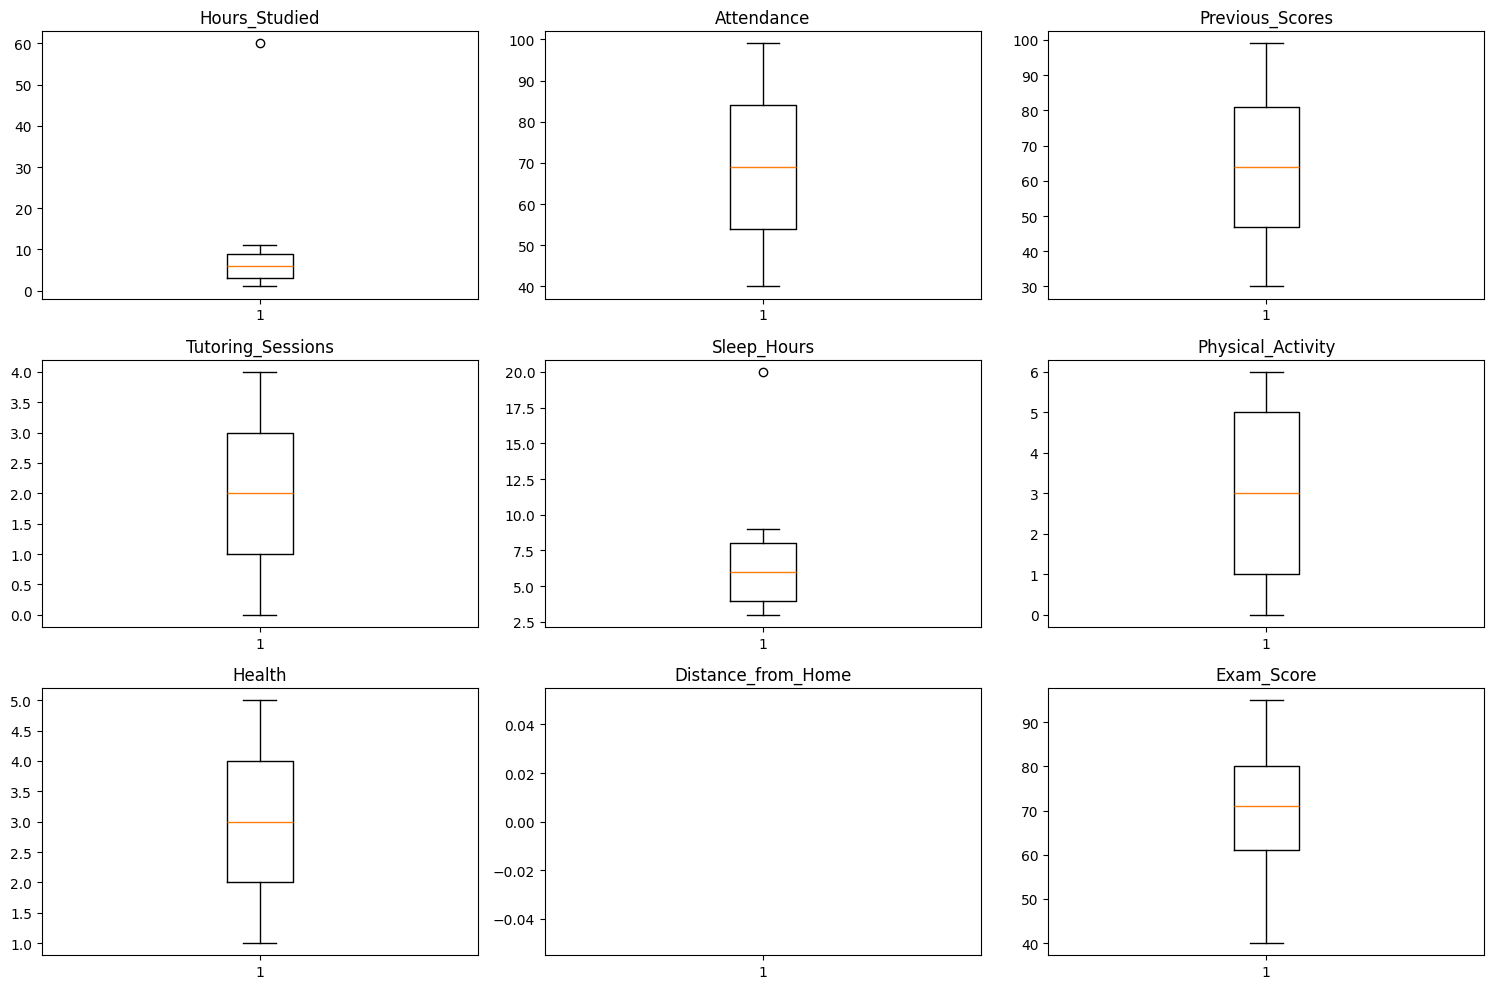

In [53]:


cols = ['Hours_Studied','Attendance','Previous_Scores',
        'Tutoring_Sessions','Sleep_Hours','Physical_Activity',
        'Health','Distance_from_Home','Exam_Score']

fig, ax = plt.subplots(3, 3, figsize=(15,10))

for i, col in enumerate(cols):
    ax[i//3, i%3].boxplot(df[col])
    ax[i//3, i%3].set_title(col)

plt.tight_layout()
plt.show()

In [54]:
print(df["Distance_from_Home"].isnull().sum())

661


In [55]:
data_clean = df['Distance_from_Home'].dropna()

In [56]:
print(data_clean.isnull().sum())

0


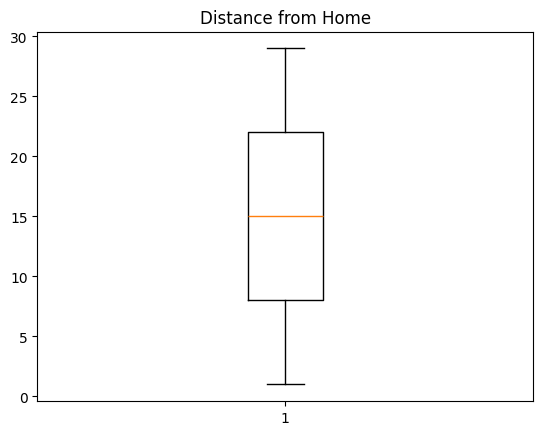

In [57]:
plt.boxplot(data_clean )
plt.title("Distance from Home")
plt.show()

In [58]:
df["Teacher_Quality"]=df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])

In [59]:
df["Parental_Education_Level"]= df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])

In [60]:
df["Distance_from_Home"]= df["Distance_from_Home"].fillna(df["Distance_from_Home"].median().round())

In [61]:
cat_cols = ['Motivation_Level', 'Teacher_Quality', 'School_Type',
            'Internet_Access', 'Family_Income', 'Parental_Involvement',
            'Parental_Education_Level', 'Peer_Influence',
            'Access_to_Resources', 'Extracurricular_Activities',
            'Study_Environment']

for col in cat_cols:
    df[col] = df[col].str.capitalize()


In [62]:
df.head(10)

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Sleep_Hours,Motivation_Level,Teacher_Quality,School_Type,Internet_Access,Family_Income,Parental_Involvement,Parental_Education_Level,Distance_from_Home,Physical_Activity,Peer_Influence,Access_to_Resources,Extracurricular_Activities,Health,Study_Environment,Exam_Score
0,7,53,58,3,8,High,Poor,Public,No,Medium,High,Graduate,28.0,1,Positive,Low,Yes,1,Average,65
1,4,53,99,1,8,Low,Average,Private,Yes,Low,High,School,15.0,2,Neutral,Low,Yes,2,Good,75
2,60,55,88,2,9,Medium,Poor,Private,No,Low,Medium,School,15.0,3,Neutral,Low,No,4,Poor,95
3,8,46,93,2,20,High,Good,Private,Yes,Medium,Low,Graduate,3.0,3,Negative,Low,No,2,Poor,95
4,5,71,53,0,5,High,Good,Private,No,Medium,Medium,Postgraduate,20.0,4,Positive,High,Yes,1,Poor,64
5,7,58,45,2,4,Medium,Poor,Private,Yes,Medium,Low,Postgraduate,4.0,6,Neutral,Medium,No,2,Poor,57
6,10,41,81,4,7,Medium,Poor,Private,Yes,High,Low,School,13.0,5,Positive,Low,Yes,1,Poor,74
7,3,49,35,1,6,High,Average,Public,Yes,High,Medium,Postgraduate,15.0,3,Positive,Medium,Yes,5,Poor,46
8,7,89,66,3,7,High,Good,Private,Yes,Medium,Low,School,20.0,2,Positive,Medium,Yes,4,Poor,84
9,11,56,33,3,8,Medium,Average,Public,Yes,Medium,Medium,School,27.0,4,Positive,High,No,1,Good,60


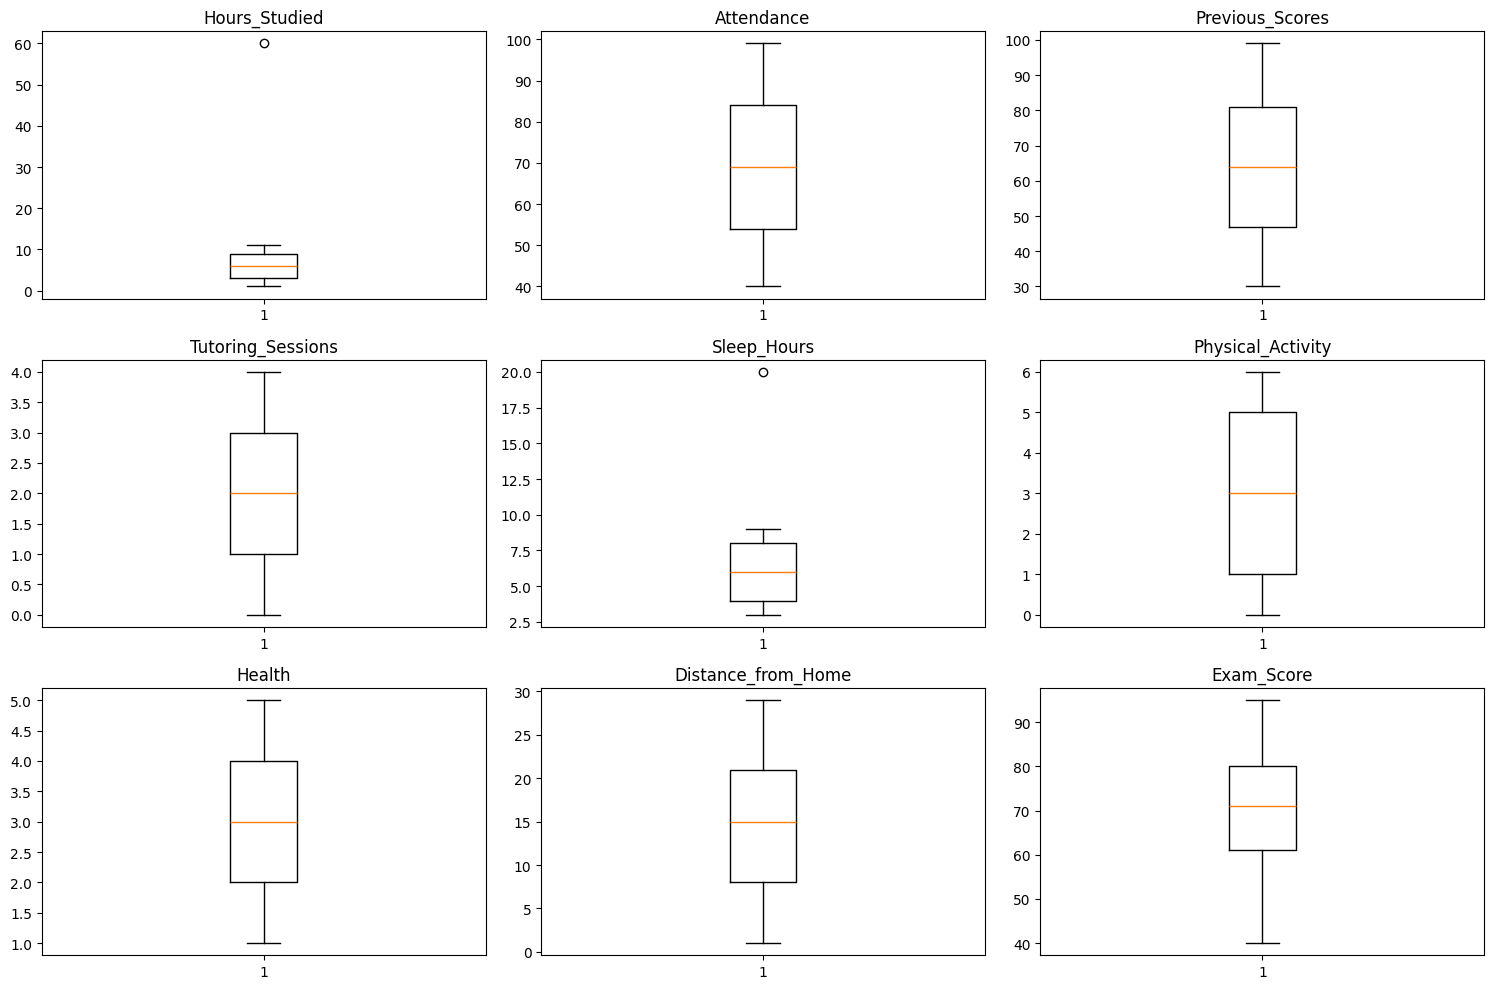

In [63]:
cols = ['Hours_Studied','Attendance','Previous_Scores',
        'Tutoring_Sessions','Sleep_Hours','Physical_Activity',
        'Health','Distance_from_Home','Exam_Score']

fig, ax = plt.subplots(3, 3, figsize=(15,10))

for i, col in enumerate(cols):
    ax[i//3, i%3].boxplot(df[col])
    ax[i//3, i%3].set_title(col)

plt.tight_layout()
plt.show()

In [64]:
cols = [
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Sleep_Hours',
    'Physical_Activity',
    'Health',
    'Distance_from_Home',
    'Exam_Score'
]

rel_exam = data[cols].corr()['Exam_Score'].sort_values(ascending=False)

rel_exam

Exam_Score            1.000000
Previous_Scores       0.713172
Attendance            0.463444
Hours_Studied         0.431591
Sleep_Hours           0.121256
Tutoring_Sessions     0.014878
Physical_Activity     0.003284
Health               -0.013053
Distance_from_Home   -0.033243
Name: Exam_Score, dtype: float64

### - Visvalization

## Numerical (single)

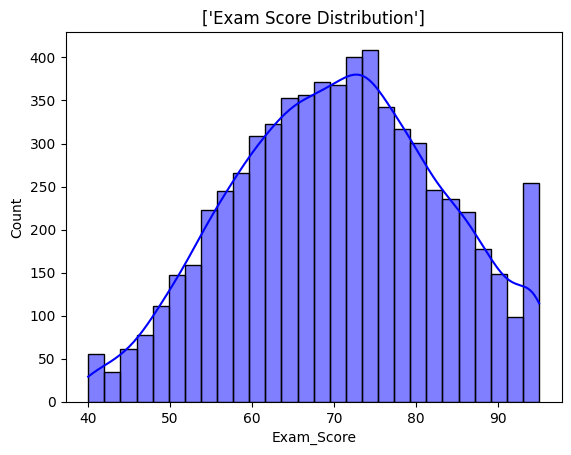

In [65]:
plt.figure()
sns.histplot(df['Exam_Score'], kde=True, color='Blue')
plt.title(["Exam Score Distribution"])
plt.show()

Insight:
Most students score around average (~70).

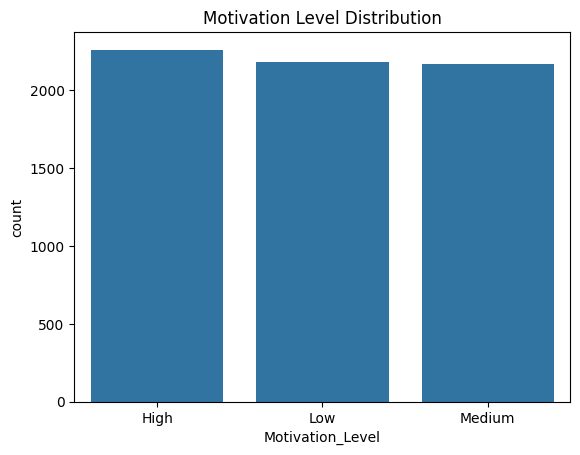

In [66]:
plt.figure()
sns.countplot(x='Motivation_Level', data=df)
plt.title("Motivation Level Distribution")
plt.show()

Insight:
Shows how students are distributed across motivation levels.

School_Type
Private    3380
Public     3228
Name: count, dtype: int64


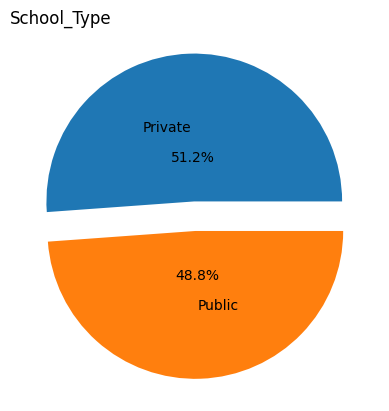

In [67]:
counts = df['School_Type'].value_counts()
print(counts)
plt.pie(counts, labels=counts.index,labeldistance=0.5,pctdistance=0.3, autopct='%1.1f%%',explode=[0.1,0.1])
plt.title('School_Type',loc='left')
plt.show()

Dataset me School_Type ka distribution dikh raha hai

## Num vs Target value

In [68]:
num_cols = [
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Sleep_Hours',
    'Physical_Activity',
    'Health',
    'Distance_from_Home'
]

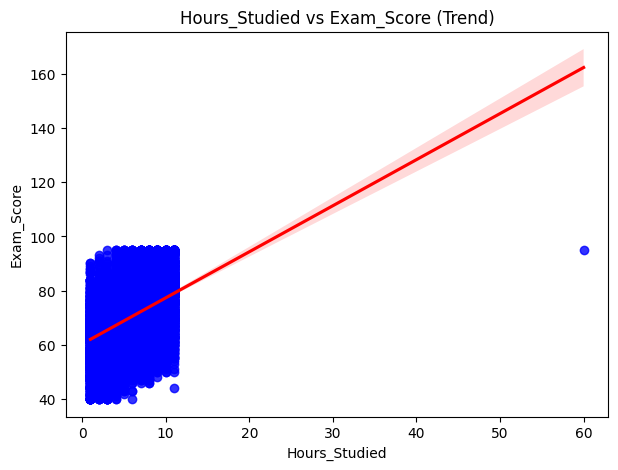

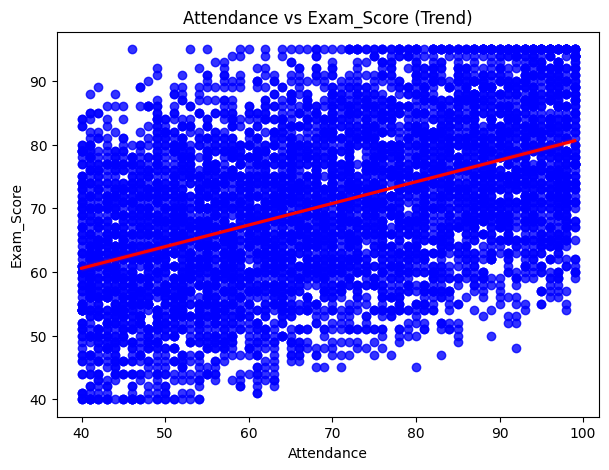

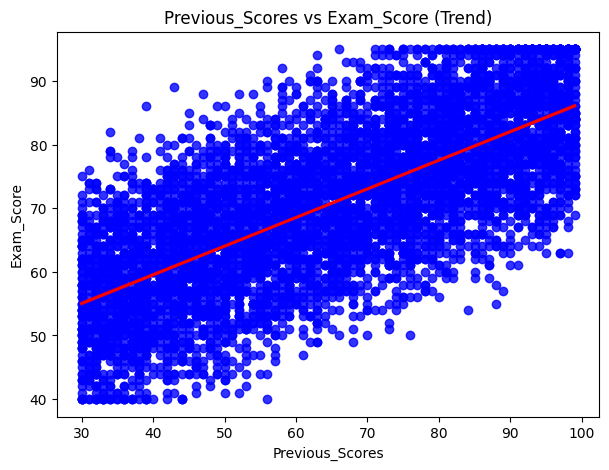

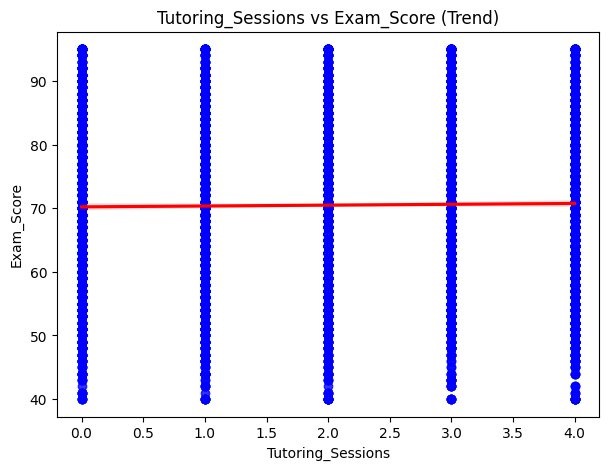

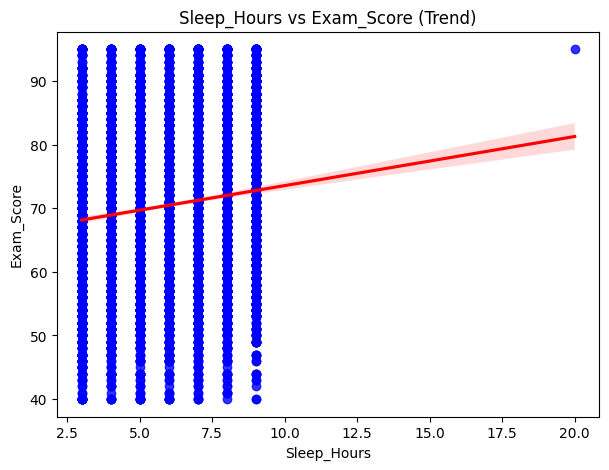

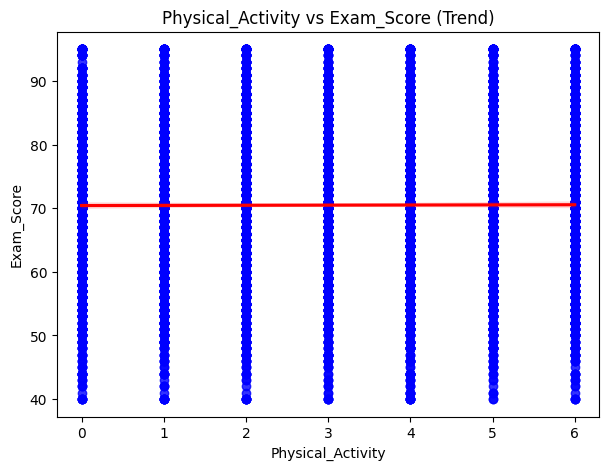

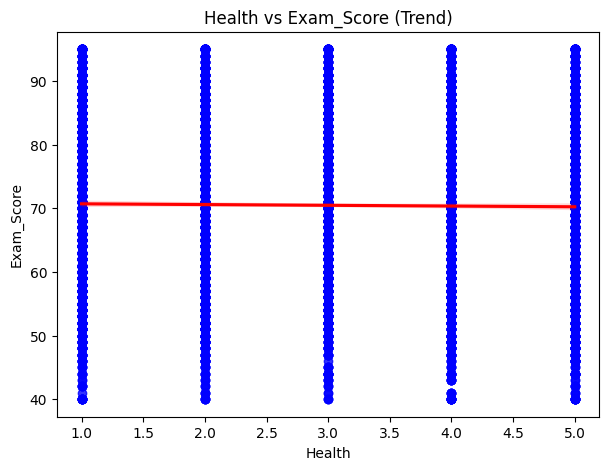

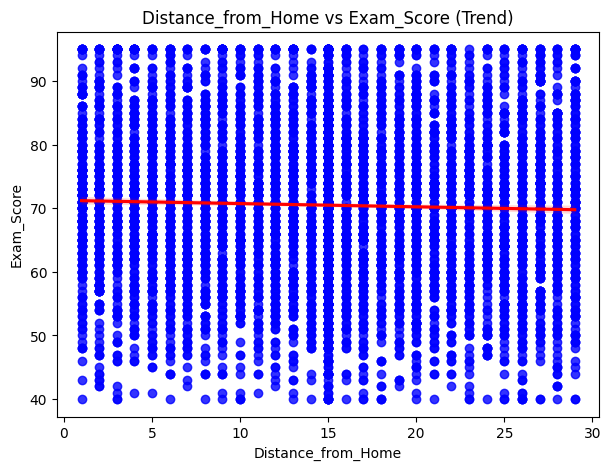

In [69]:
for col in num_cols:
    plt.figure(figsize=(7,5))
    sns.regplot(x=col, y='Exam_Score', data=df,scatter_kws={'color': 'blue'},line_kws={'color': 'red'}   )
    plt.title(f"{col} vs Exam_Score (Trend)")
    plt.show()

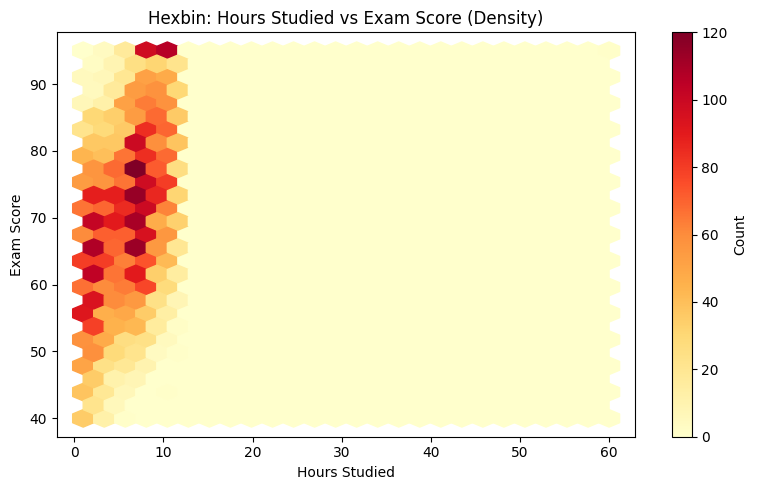

In [70]:
plt.figure(figsize=(8, 5))
plt.hexbin(df['Hours_Studied'], df['Exam_Score'], gridsize=25,
           cmap='YlOrRd')
plt.colorbar(label='Count')
plt.title('Hexbin: Hours Studied vs Exam Score (Density)')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

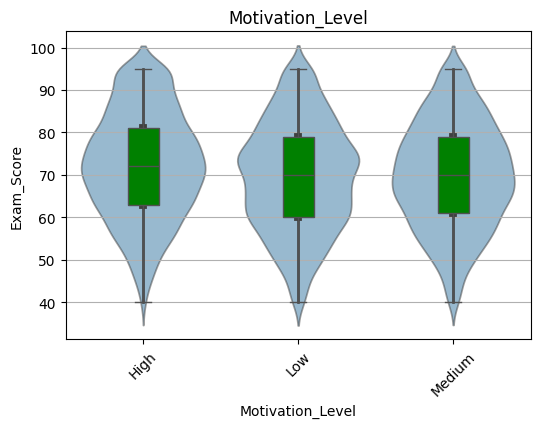

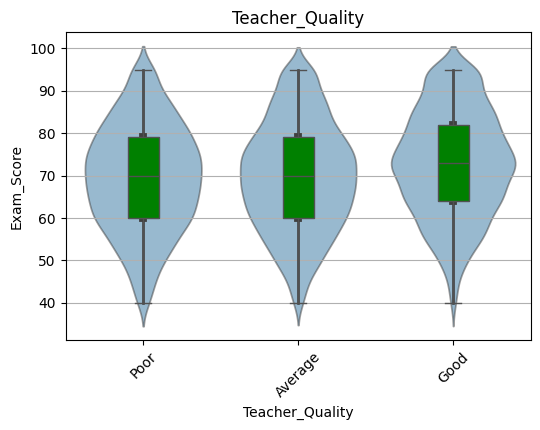

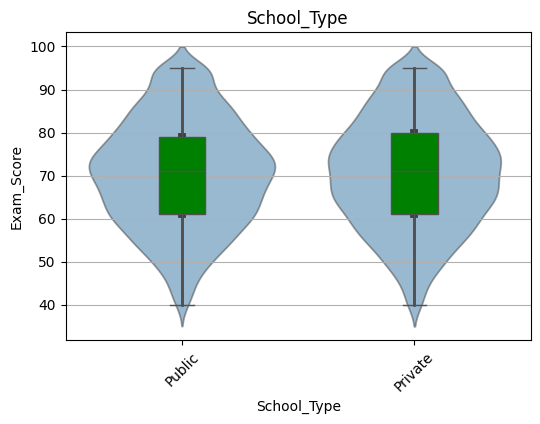

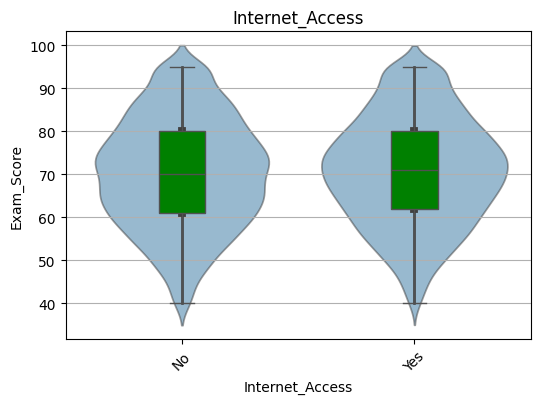

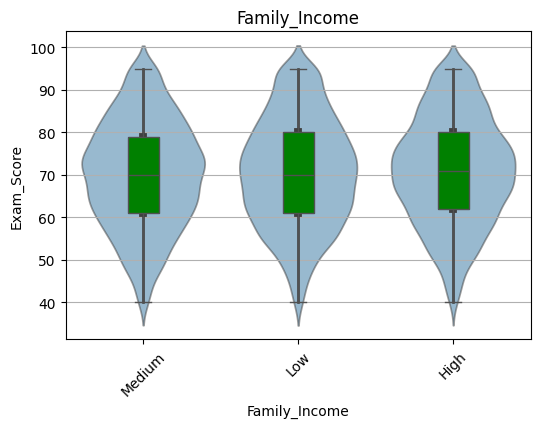

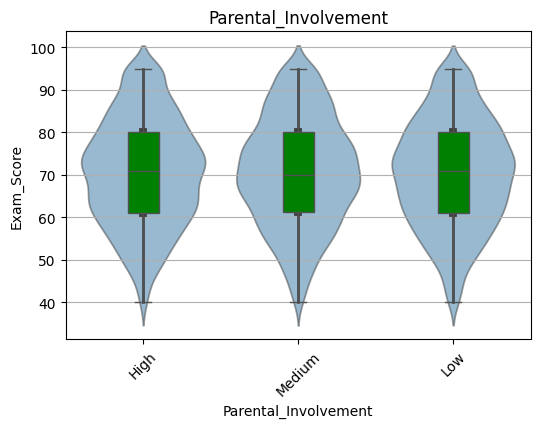

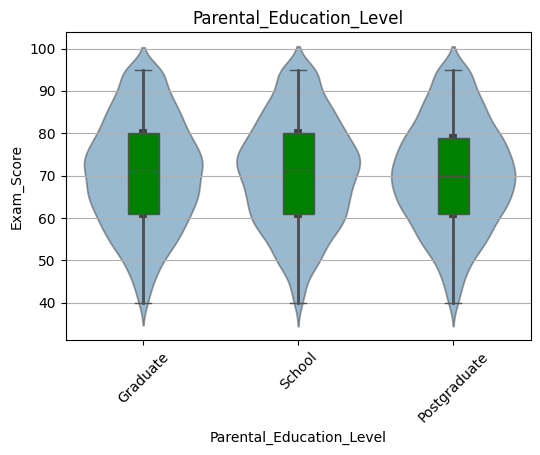

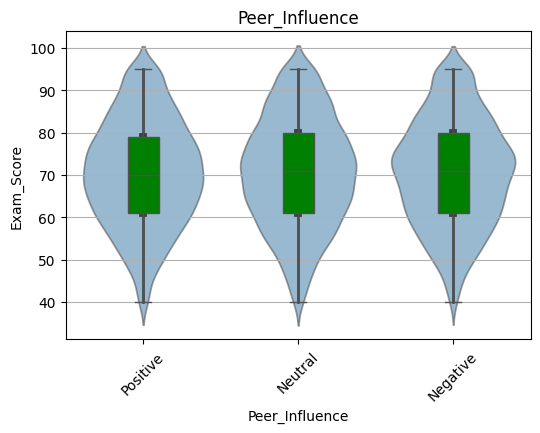

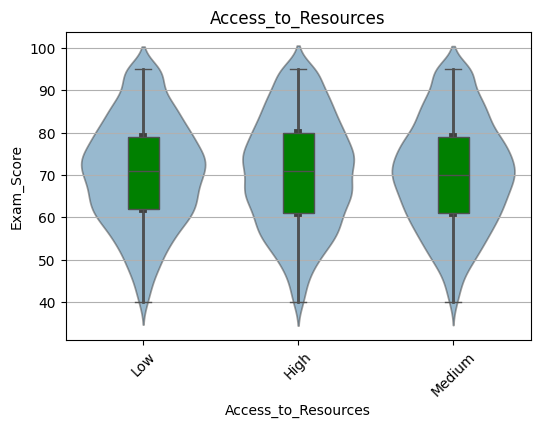

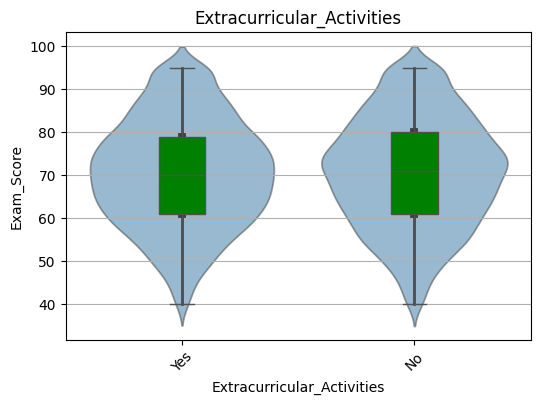

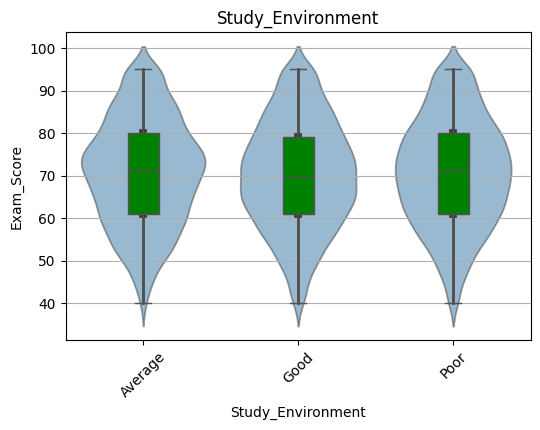

In [71]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    
    sns.violinplot(
        x=col,
        y='Exam_Score',
        data=df,
        
        alpha=0.5
    )
    
    sns.boxplot(
        x=col,
        y='Exam_Score',
        data=df,
        width=0.2,
        boxprops={'facecolor':'Green'}
    )
    
    plt.title(col)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()

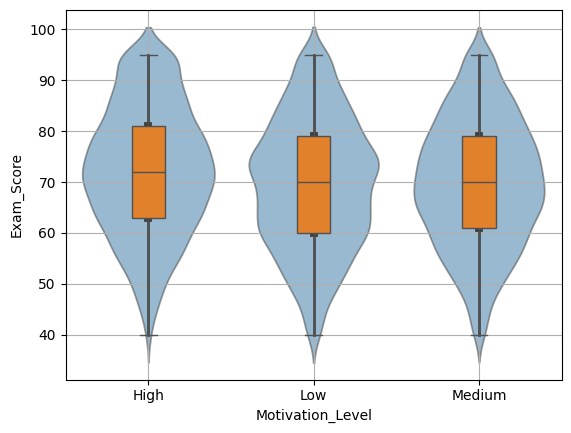

In [72]:
sns.violinplot(x='Motivation_Level', y='Exam_Score', data=df, alpha=0.5)
sns.boxplot(x='Motivation_Level', y='Exam_Score', data=df, width=0.2)
plt.grid()
plt.show()

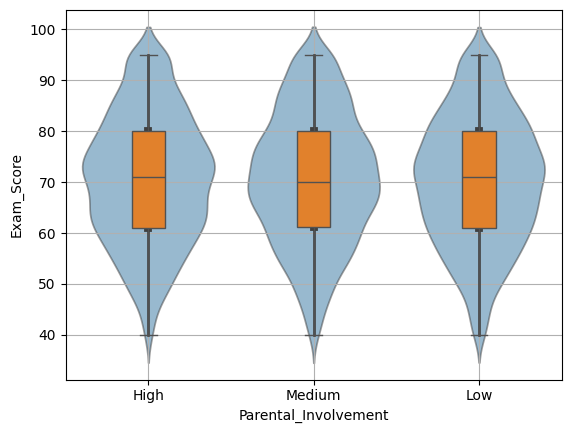

In [73]:
sns.violinplot(x='Parental_Involvement', y='Exam_Score', data=df, alpha=0.5)
sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=df, width=0.2)
plt.grid()
plt.show()

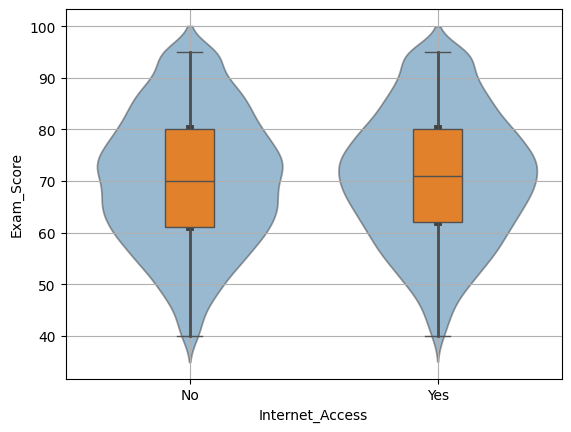

In [74]:
sns.violinplot(x='Internet_Access', y='Exam_Score', data=df, alpha=0.5)
sns.boxplot(x='Internet_Access', y='Exam_Score', data=df, width=0.2)
plt.grid()
plt.show()

## 2 categorical

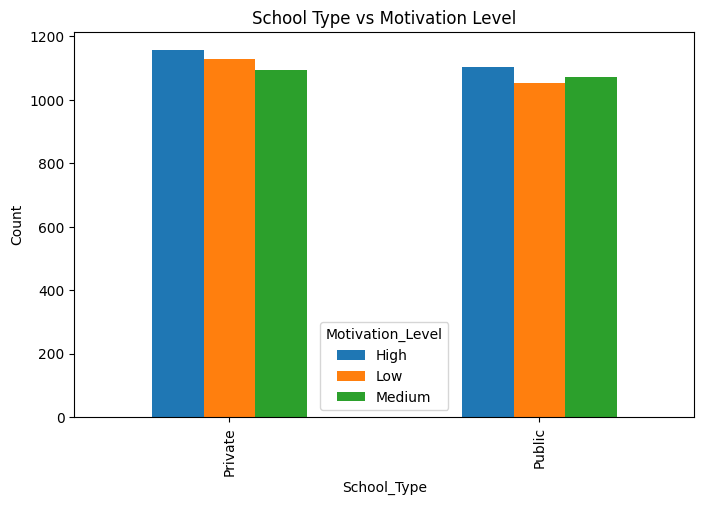

In [75]:
data = df.groupby(['School_Type', 'Motivation_Level']).size().unstack()

data.plot(kind='bar', figsize=(8,5))
plt.title("School Type vs Motivation Level")
plt.ylabel("Count")
plt.show()

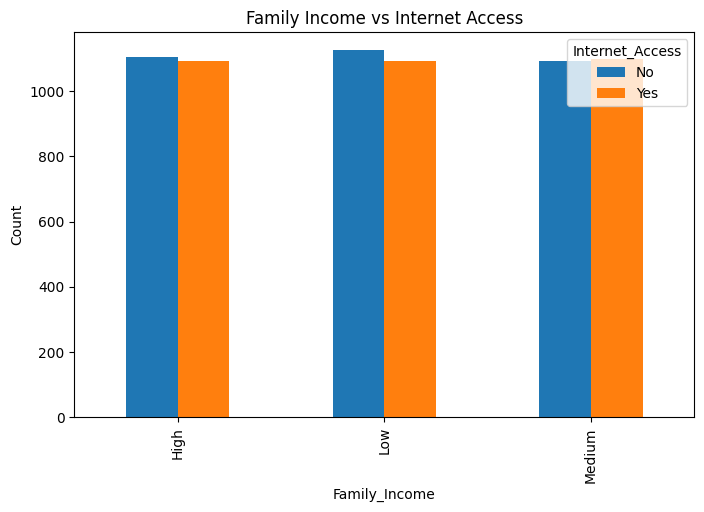

In [76]:
data = df.groupby(['Family_Income', 'Internet_Access']).size().unstack()

data.plot(kind='bar', figsize=(8,5))
plt.title("Family Income vs Internet Access")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='School_Type'>

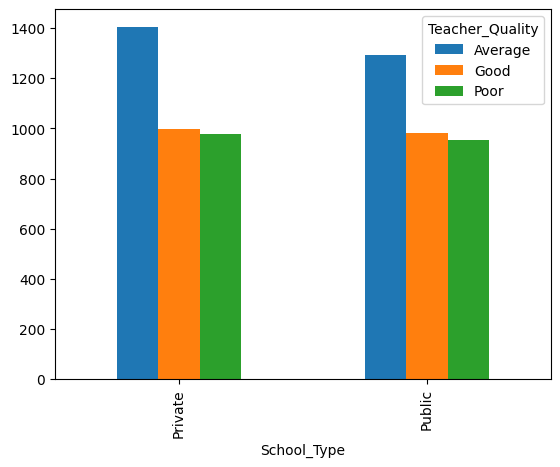

In [77]:
pd.crosstab(df['School_Type'], df['Teacher_Quality']).plot(
    kind='bar',
    stacked=False
    )


<Axes: xlabel='Parental_Involvement'>

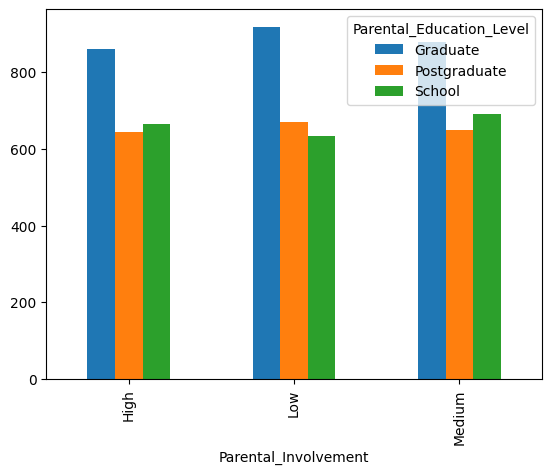

In [78]:
pd.crosstab(df['Parental_Involvement'], df['Parental_Education_Level']).plot(
    kind='bar',
    stacked=False
    )


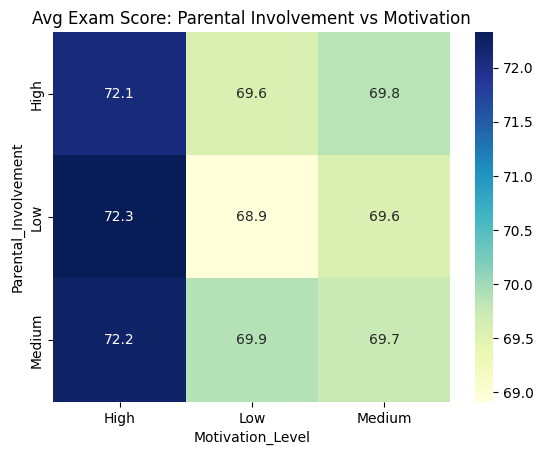

In [79]:
pivot = df.pivot_table(values='Exam_Score', index='Parental_Involvement', columns='Motivation_Level', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title("Avg Exam Score: Parental Involvement vs Motivation")
plt.show()

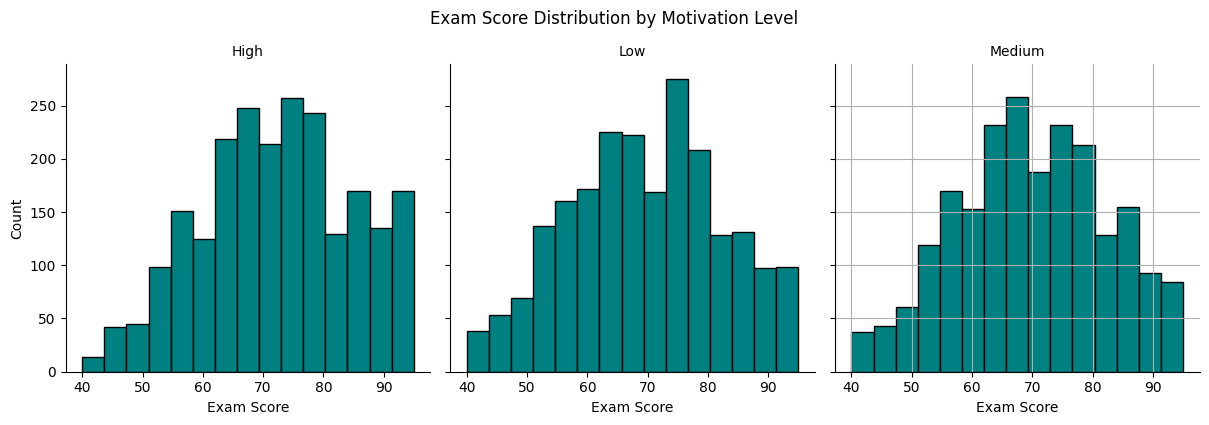

In [80]:
g = sns.FacetGrid(df, col='Motivation_Level', height=4, aspect=1)
g.map(plt.hist, 'Exam_Score', bins=15, color='teal', edgecolor='black')
g.set_titles("{col_name}")
g.set_axis_labels('Exam Score', 'Count')
plt.suptitle('Exam Score Distribution by Motivation Level', y=1.05)
plt.grid()
plt.show()

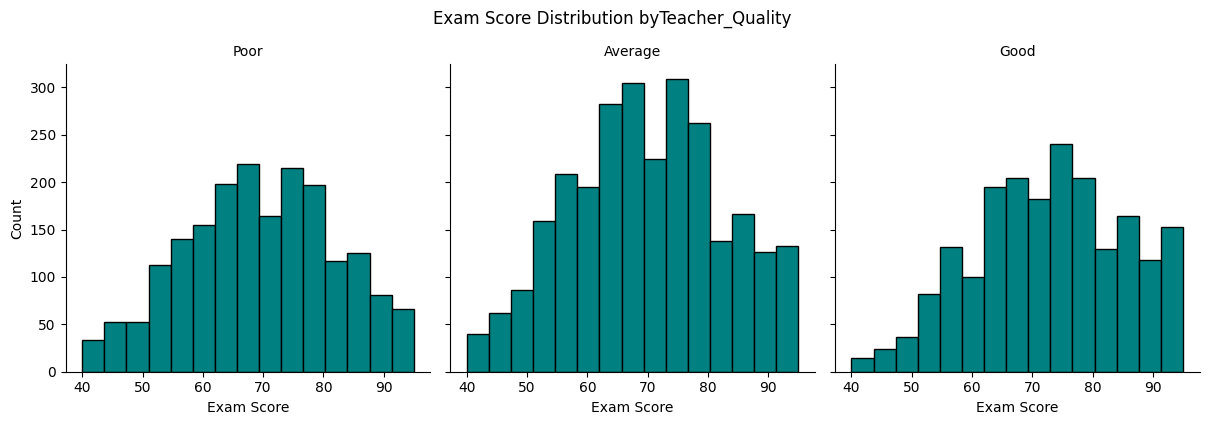

In [81]:
g = sns.FacetGrid(df, col='Teacher_Quality', height=4, aspect=1)
g.map(plt.hist, 'Exam_Score', bins=15, color='teal', edgecolor='black')
g.set_titles("{col_name}")
g.set_axis_labels('Exam Score', 'Count')
plt.suptitle('Exam Score Distribution byTeacher_Quality ', y=1.05)
plt.show()

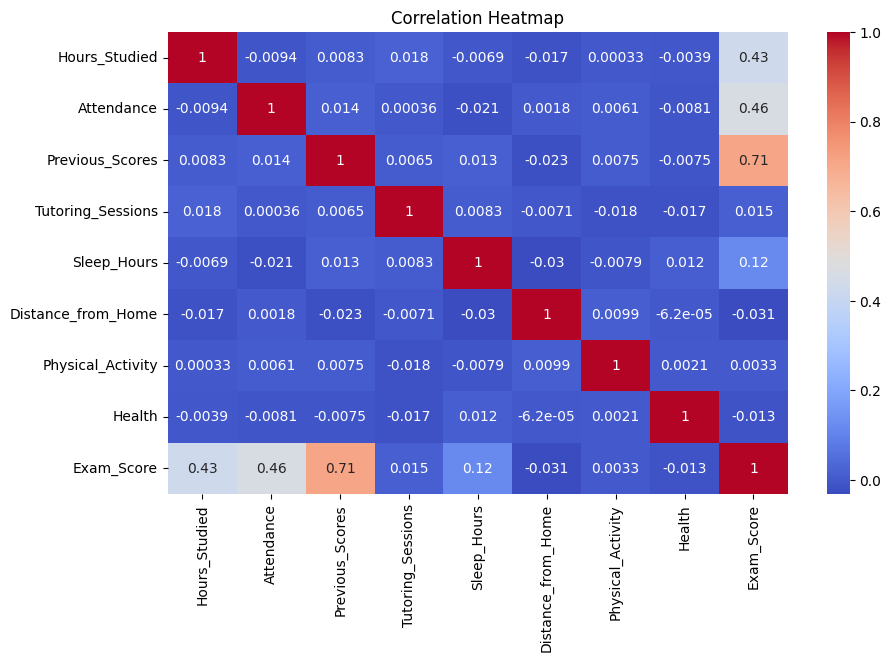

In [82]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [83]:
df_encoded=df.copy()

In [84]:
 # Mapping all categorical columns

df_encoded['Motivation_Level'] = df['Motivation_Level'].map({
    'Low': 0, 'Medium': 1, 'High': 2
})
df_encoded['Teacher_Quality'] = df['Teacher_Quality'].map({
    'Poor': 0, 'Average': 1, 'Good': 2
})
df_encoded['School_Type'] = df['School_Type'].map({
    'Public': 0, 'Private': 1
})
df_encoded['Internet_Access'] = df['Internet_Access'].map({
    'No': 0, 'Yes': 1
})
df_encoded['Family_Income'] = df['Family_Income'].map({
    'Low': 0, 'Medium': 1, 'High': 2
})
df_encoded['Parental_Involvement'] = df['Parental_Involvement'].map({
    'Low': 0, 'Medium': 1, 'High': 2
})
df_encoded['Parental_Education_Level'] = df['Parental_Education_Level'].map({
    'School': 0, 'Graduate': 1, 'Postgraduate': 2
})
df_encoded['Peer_Influence'] = df['Peer_Influence'].map({
    'Negative': 0, 'Neutral': 1, 'Positive': 2
})
df_encoded['Access_to_Resources'] = df['Access_to_Resources'].map({
    'Low': 0, 'Medium': 1, 'High': 2
})
df_encoded['Extracurricular_Activities'] = df['Extracurricular_Activities'].map({
    'No': 0, 'Yes': 1
})
df_encoded['Study_Environment'] = df['Study_Environment'].map({
    'Poor': 0, 'Average': 1, 'Good': 2
})


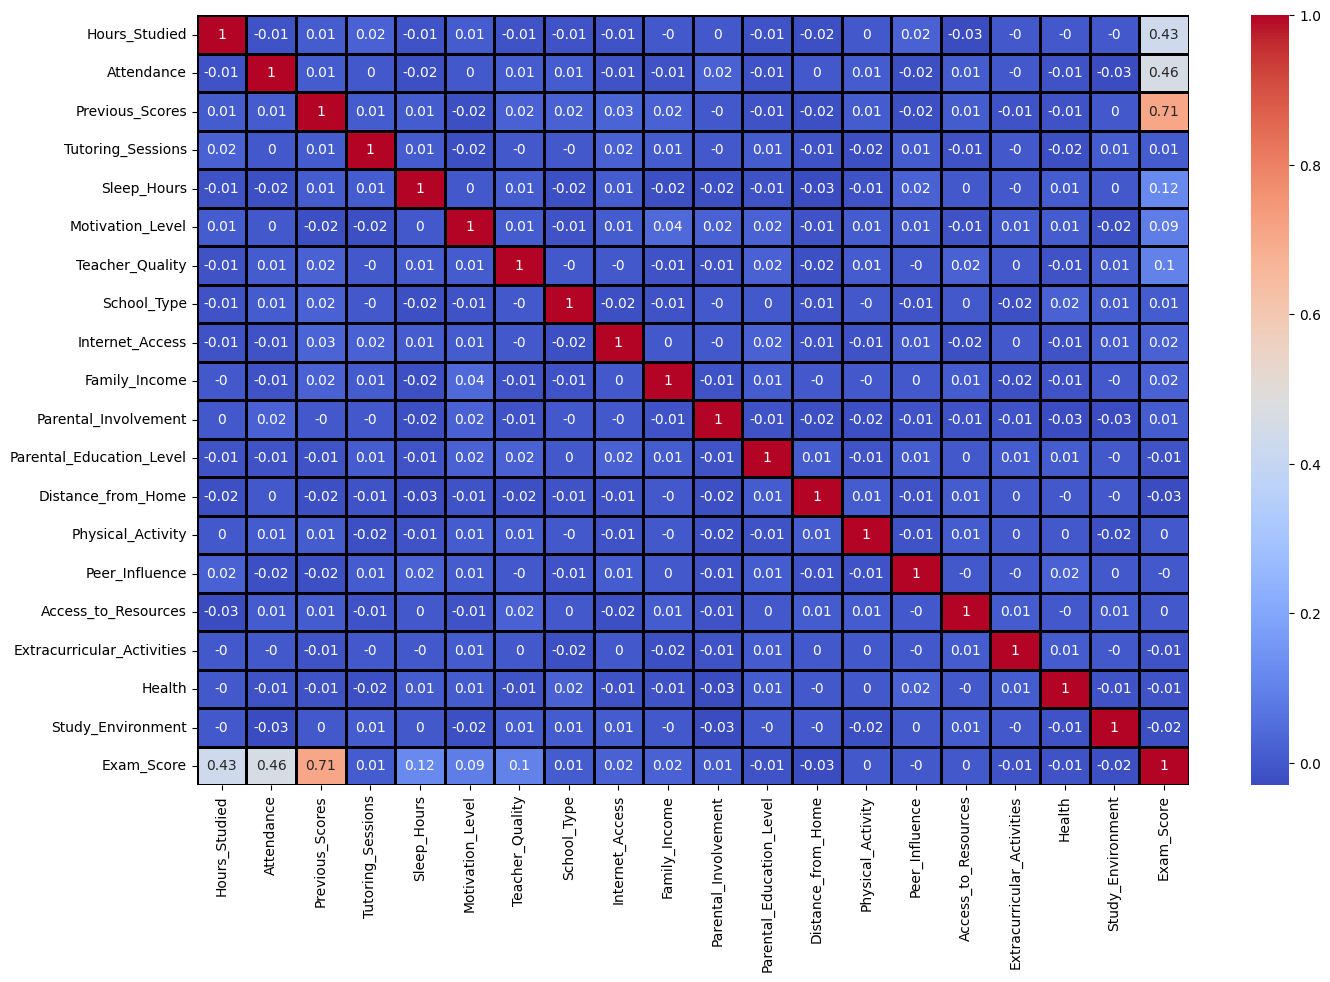

In [85]:
plt.figure(figsize=(16,10))
corr = df_encoded.corr().round(2)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
     linewidths=1,        # 👈 border thickness
           linecolor='black'
)
plt.show()

📊 MODEL PERFORMANCE
R2 Score: 0.9389996169423194
MAE: 2.5039814484081537
MSE: 9.784449973144087


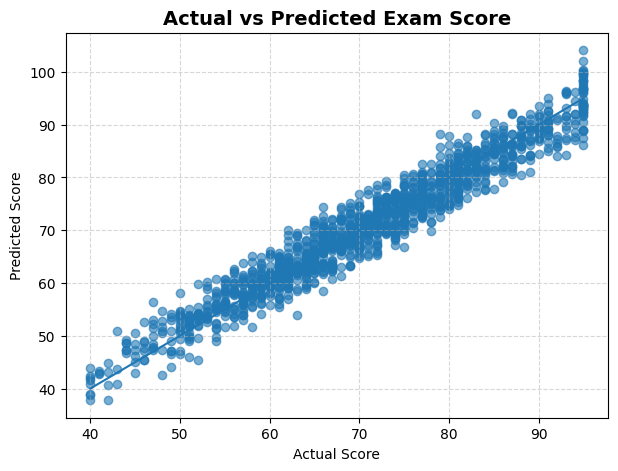

In [86]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# =========================
# DEFINE X AND y
# =========================
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# =========================
# ENCODING
# =========================
X = pd.get_dummies(X, drop_first=True)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# MODEL
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# METRICS
# =========================
print("📊 MODEL PERFORMANCE")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# =========================
# GRAPH: ACTUAL vs PREDICTED
# =========================
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")

plt.title("Actual vs Predicted Exam Score", fontsize=14, fontweight='bold')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()



In [87]:
# =========================
# SAVE MODEL
# =========================
joblib.dump(model, "student_model.pkl")
joblib.dump(X.columns, "model_columns.pkl")

print("\n✅ Model saved successfully!")


✅ Model saved successfully!
